In [1]:
import os
import numpy as np
from vector_field import *
from linear_ode import *
os.makedirs('generated_plot_images', exist_ok=True)

# ODE Visualisation Playground

A walkthrough of the two companion modules in this toolkit:

| Module | Role |
|---|---|
| `vector_field.py` | Quiver / slope-field plots for any first-order ODE $\dfrac{dy}{dx} = F(x, y)$ |
| `linear_ode.py` | Analytical solutions for the linear ODE $y' = a\,y + q(x)$ for four canonical sources |

The general first-order linear ODE

$$y' - a\,y = q(x)$$

is solved with the integrating factor $\mu(x) = e^{-a x}$, giving the **Duhamel (variation of parameters) formula**

$$y(x) \;=\; \underbrace{y_0\, e^{a x}}_{\text{homogeneous}} \;+\; \underbrace{\int_0^x e^{a(x - t)}\, q(t)\, dt}_{\text{particular}}$$

The homogeneous mode $y_0 e^{a x}$ **decays** when $a < 0$ (stable) and **grows** when $a > 0$ (unstable). The particular integral convolves the source $q$ with the system's impulse response $e^{a x}$.

The first three cells exercise `plot_case(...)` from `linear_ode.py` (solution curve + slope field side-by-side); the rest call `plot_vector_field(...)` directly to explore custom right-hand sides.

## Constant source — `plot_case('constant')`

For the linear ODE

$$y' = a\,y + q_0$$

with a constant forcing $q_0$, the analytical solution is

$$y(x) = \left(y_0 + \frac{q_0}{a}\right) e^{a x} - \frac{q_0}{a}, \qquad (a \neq 0)$$

When $a < 0$, every trajectory converges to the **steady state** $y^{*} = -\dfrac{q_0}{a}$ regardless of the initial condition.

In the cell below, with $a = -6$, $y_0 = 0$, $q_0 = 3$, the system rushes to its steady state $y^{*} = 0.5$ in a very short transient — the large $|a|$ collapses the homogeneous mode almost instantly.

Saved → generated_plot_images/const_case.png


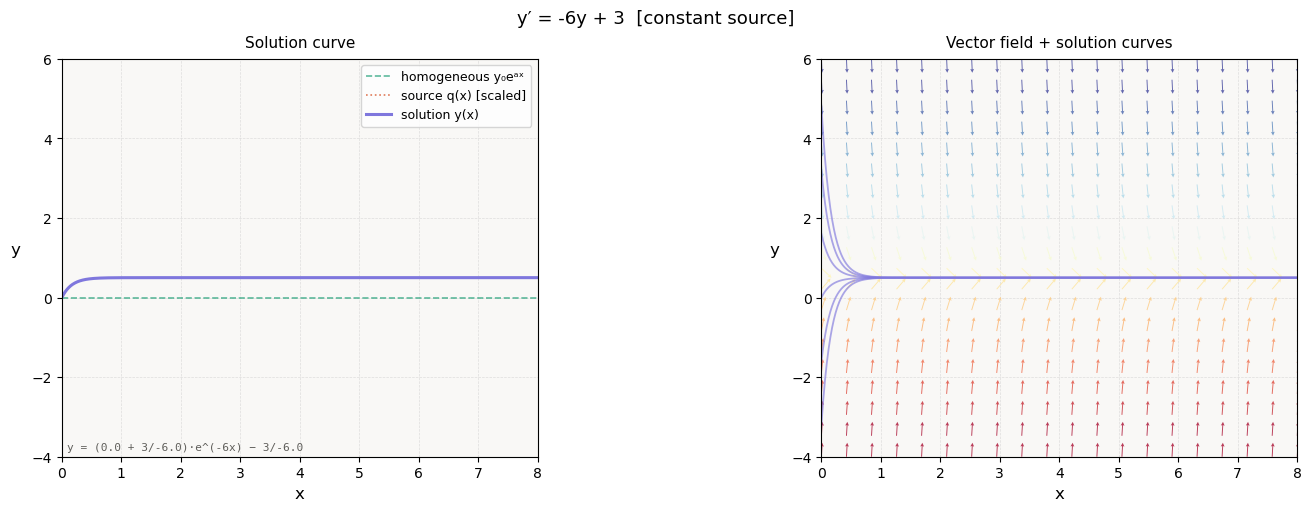

In [2]:
# solution curve only (vector_field.py not present)
fig = plot_case('constant', a=-6, y0=0, q0=3, save_path='generated_plot_images/const_case.png')


## Step source — `plot_case('step')`

A Heaviside switch at $x = x_0$,

$$q(x) = q_0\, H(x - x_0) = \begin{cases} 0 & x < x_0 \\ q_0 & x \geq x_0 \end{cases}$$

splits the solution into two regimes:

$$y(x) = \begin{cases} y_0\, e^{a x} & x < x_0 \\[6pt] y_0\, e^{a x} + \dfrac{q_0}{a}\!\left(e^{a(x - x_0)} - 1\right) & x \geq x_0 \end{cases}$$

$y$ stays **continuous** across $x_0$, but $y'$ jumps by $q_0$ — the solution shows a visible *kink*, not a discontinuity.

Below, $a = -0.5$, $y_0 = 1$, $q_0 = 3$, $x_0 = 3$: before the switch the trajectory decays toward zero, and after the switch it pivots and climbs toward the new steady state $y^{*} = -q_0 / a = 6$.

Saved → generated_plot_images/step_case.png


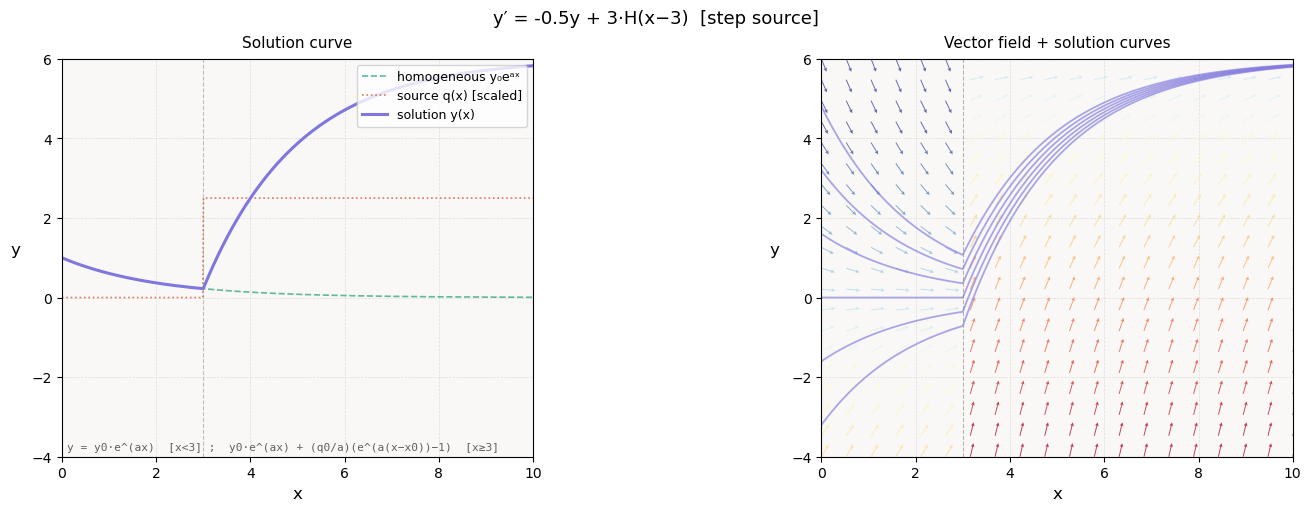

In [3]:
# solution curve + vector field side by side (vector_field.py present)
fig = plot_case('step', a=-0.5, y0=1, q0=3, x0=3, x_range=(0, 10), save_path='generated_plot_images/step_case.png')

## Exponential source — `plot_case('exp')`

When $q(x) = q_0\, e^{b x}$ and $b \neq a$, the Duhamel integral evaluates to

$$y(x) = y_0\, e^{a x} + \frac{q_0}{b - a}\!\left(e^{b x} - e^{a x}\right)$$

The solution is a superposition of two exponentials: the homogeneous mode $e^{a x}$ and the source-driven mode $e^{b x}$.

With $a = -1$, $q_0 = 2$, $b = 0.5$ below, the system is stable ($a < 0$) but the source grows ($b > 0$), so the long-term behaviour is dominated by $e^{0.5 x}$ — the climbing source eventually overtakes the decaying homogeneous part.

Saved → generated_plot_images/exp_case.png


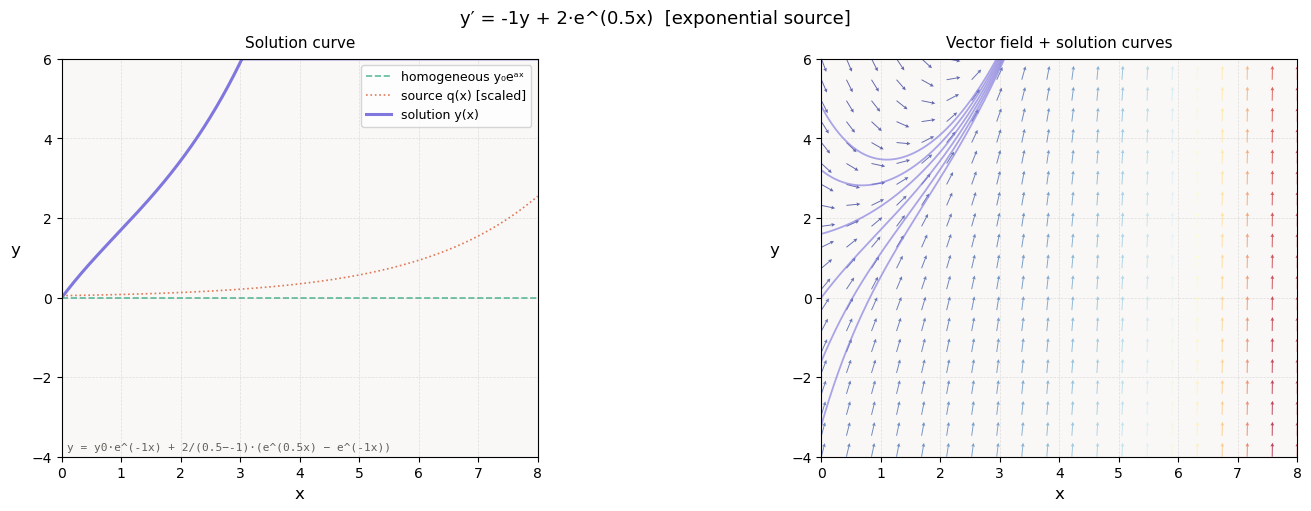

In [4]:

# save instead of showing
fig = plot_case('exp', a=-1, q0=2, b=0.5, save_path='generated_plot_images/exp_case.png')

---

# Direct slope-field plots via `plot_vector_field`

Switching from the bundled `plot_case` helper to `plot_vector_field` directly: any ODE of the form $\dfrac{dy}{dx} = F(x, y)$ can be visualised as a slope field. Arrow **direction** encodes the sign and ratio of $F$ at that point; arrow **colour** encodes $|F|$ (slope magnitude). Solution curves are overlaid automatically.

## Vector field — constant source

For a constant source $F(x, y) = a\, y + q_0$ the right-hand side depends only on $y$, so the slope field is **horizontally invariant** — every column shows the same arrows. The equilibrium appears as a flat row at $y^{*} = -q_0 / a$.

$$y' = -y + 2, \qquad a = -1,\ q_0 = 2,\ y^{*} = 2$$

Saved to generated_plot_images/constant_field.png


(<Figure size 1100x600 with 2 Axes>,
 <Axes: title={'center': 'y′ = −y + 2  [constant, a=−1, q₀=2]'}, xlabel='x', ylabel='y'>)

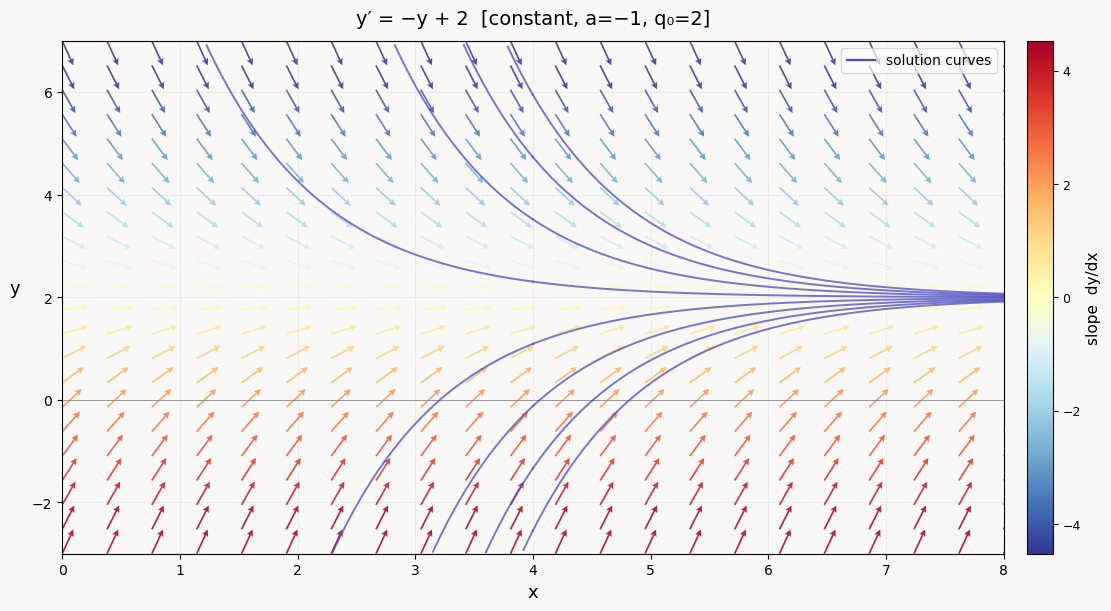

In [5]:
# ── constant source ───────────────────────────────────────────────────────────
plot_vector_field(
    F       = lambda x, y: -1.0 * y + 2.0,
    x_range = (0, 8),
    y_range = (-3, 7),
    density = 22,
    title   = "y′ = −y + 2  [constant, a=−1, q₀=2]",
    save_path='generated_plot_images/constant_field.png',
)

## Vector field — step source

Embedding the Heaviside switch directly inside the lambda yields a slope field that is **piecewise constant in $x$**: arrows are autonomous to the left of $x_0 = 2.5$, then snap to a new pattern to the right.

$$y' = -y + 2\,H(x - 2.5)$$

The equilibrium jumps from $y^{*} = 0$ (left half) to $y^{*} = 2$ (right half) at the switch.

Saved to generated_plot_images/step_field.png


(<Figure size 1100x600 with 2 Axes>,
 <Axes: title={'center': 'y′ = −y + 2·H(x−2.5)  [step source]'}, xlabel='x', ylabel='y'>)

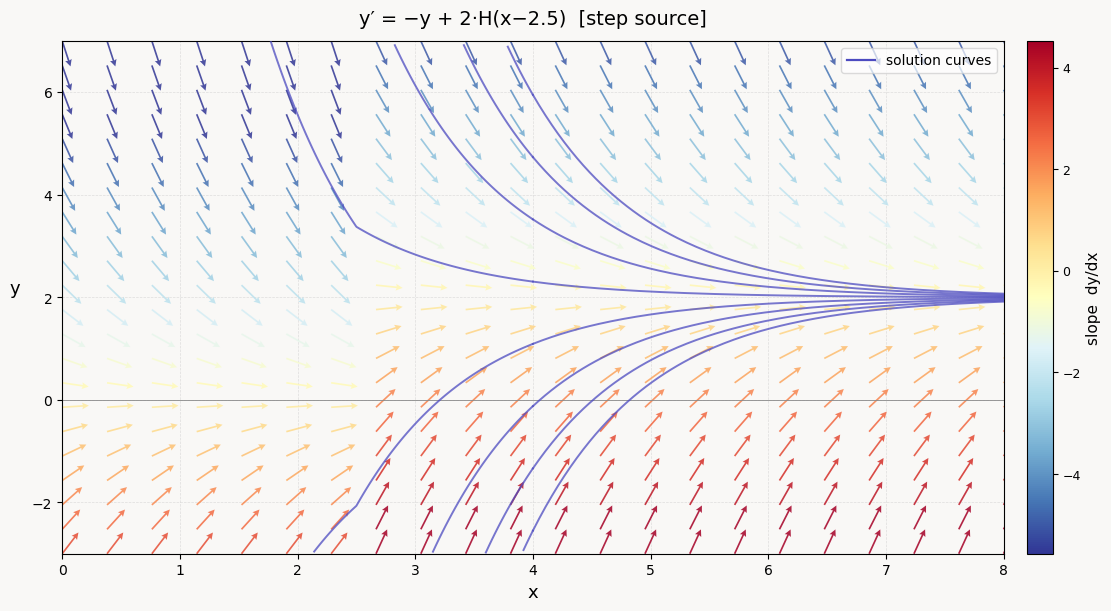

In [6]:
# ── step source H(x − 2.5) ───────────────────────────────────────────────────
plot_vector_field(
    F       = lambda x, y: -y + 2.0 * np.where(np.asarray(x) >= 2.5, 1.0, 0.0),
    x_range = (0, 8),
    y_range = (-3, 7),
    density = 22,
    title   = "y′ = −y + 2·H(x−2.5)  [step source]",
    save_path='generated_plot_images/step_field.png',
)

## Vector field — delta source

The Dirac delta $\delta(x - x_0)$ is a **distribution**, not a function — it cannot be evaluated pointwise on a grid. The slope field below therefore shows only the homogeneous equation

$$y' = a\,y$$

everywhere. The actual effect of $q_0\,\delta(x - x_0)$ is a **vertical jump** of size $q_0$ in the solution curve at $x = x_0$; after the kick, free homogeneous decay resumes from $y(x_0^{+}) = y_0\, e^{a x_0} + q_0$:

$$y(x) = \begin{cases} y_0\, e^{a x} & x < x_0 \\[6pt] \!\left(y_0\, e^{a x_0} + q_0\right) e^{a(x - x_0)} & x \geq x_0 \end{cases}$$

To *see* the jump, use `plot_case('delta', ...)` (above) which overlays the analytical `solve_delta` curve on top of the homogeneous field.

Saved to generated_plot_images/delta_field.png


(<Figure size 1100x600 with 2 Axes>,
 <Axes: title={'center': 'y′ = −y  [homogeneous field between delta kicks]'}, xlabel='x', ylabel='y'>)

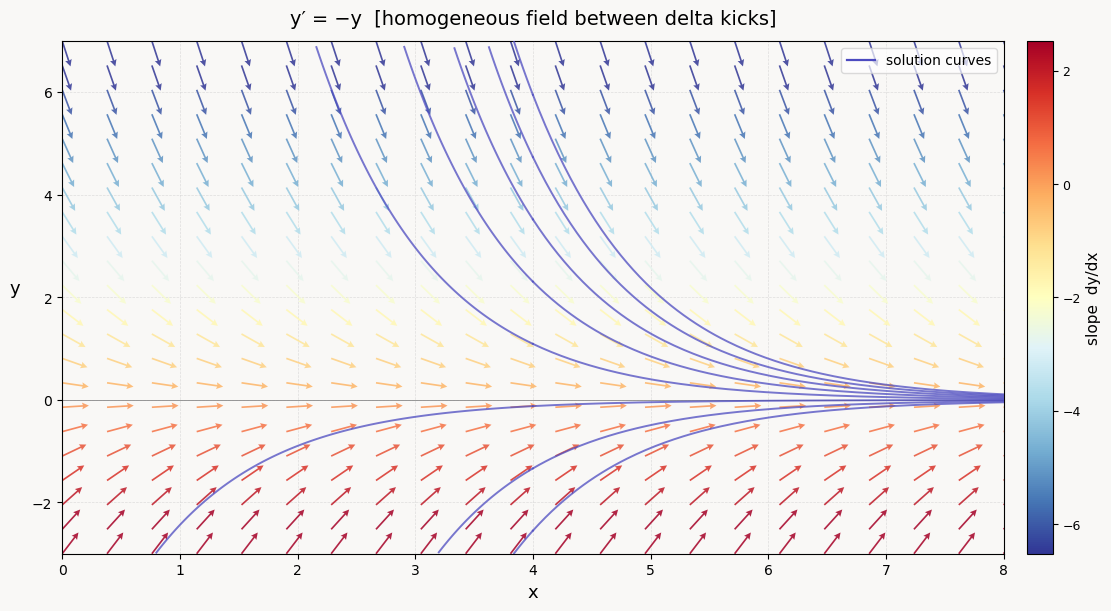

In [7]:
# ── delta source (homogeneous field between kicks) ────────────────────────────
# The vector field shows y′ = ay; the delta effect is a vertical jump in the
# solution curve at x₀, handled by linear_ode.solve_delta.
plot_vector_field(
    F       = lambda x, y: -1.0 * y,
    x_range = (0, 8),
    y_range = (-3, 7),
    density = 22,
    title   = "y′ = −y  [homogeneous field between delta kicks]",
    save_path='generated_plot_images/delta_field.png',
)

## Vector field — exponential source

With

$$y' = -y + 2\,e^{0.5 x}, \qquad b = 0.5,\ a = -1$$

the source pumps energy in faster than the system can dissipate it, so the arrows steepen rapidly as $x$ grows. The closed-form solution is

$$y(x) = y_0\, e^{-x} + \tfrac{4}{3}\!\left(e^{0.5 x} - e^{-x}\right)$$

— a sum of the (decaying) homogeneous mode and the (growing) source-driven mode.

Saved to generated_plot_images/exp_field.png


(<Figure size 1100x600 with 2 Axes>,
 <Axes: title={'center': 'y′ = −y + 2·e^(0.5x)  [exponential source]'}, xlabel='x', ylabel='y'>)

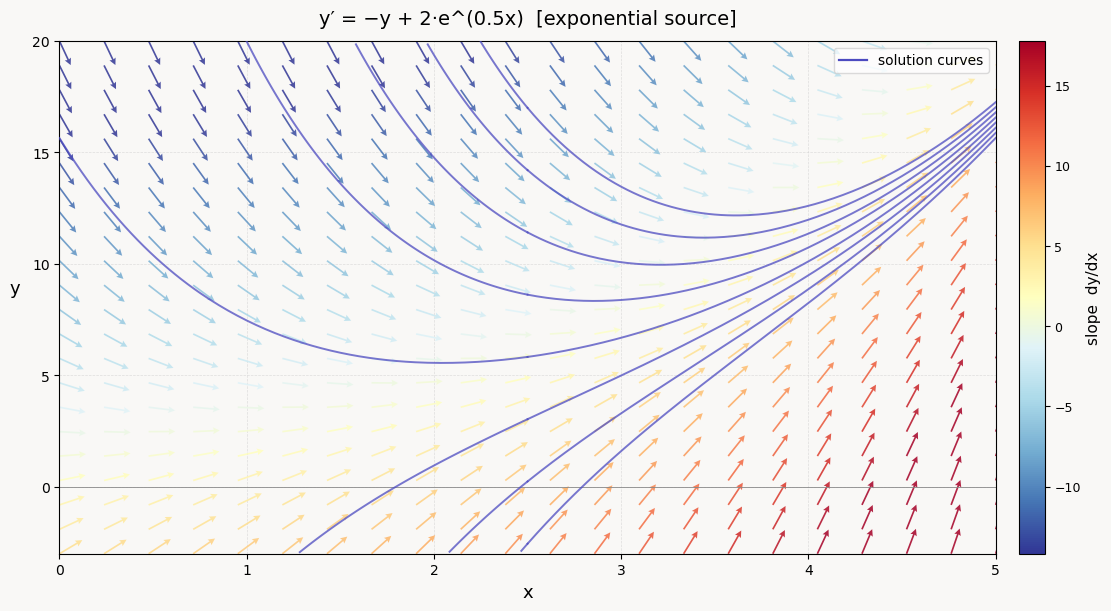

In [8]:
# ── exponential source ────────────────────────────────────────────────────────
plot_vector_field(
    F       = lambda x, y: -y + 2.0 * np.exp(0.5 * np.asarray(x, float)),
    x_range = (0, 5),
    y_range = (-3, 20),
    density = 22,
    title   = "y′ = −y + 2·e^(0.5x)  [exponential source]",
    save_path='generated_plot_images/exp_field.png',
)

## Resonance — $b = a$

When the source rate $b$ coincides with the natural rate $a$, the "normal" exponential formula breaks down (denominator $b - a = 0$). Taking the limit $b \to a$ gives the **resonance solution**

$$y(x) = \left(y_0 + q_0\, x\right) e^{a x}$$

A polynomial envelope $x$ rides on top of the exponential — the system amplifies in-phase forcing into transient linear growth before the exponential factor eventually re-dominates.

Here $a = -1$, $q_0 = 2$, so

$$y(x) = (y_0 + 2x)\, e^{-x}$$

— a bump that rises early, peaks at $x = 1 - y_0/2$, and then decays back to zero.

Saved to generated_plot_images/resonance_field.png


(<Figure size 1100x600 with 2 Axes>,
 <Axes: title={'center': 'y′ = −y + 2·e^(−x)  [resonance: b = a = −1]'}, xlabel='x', ylabel='y'>)

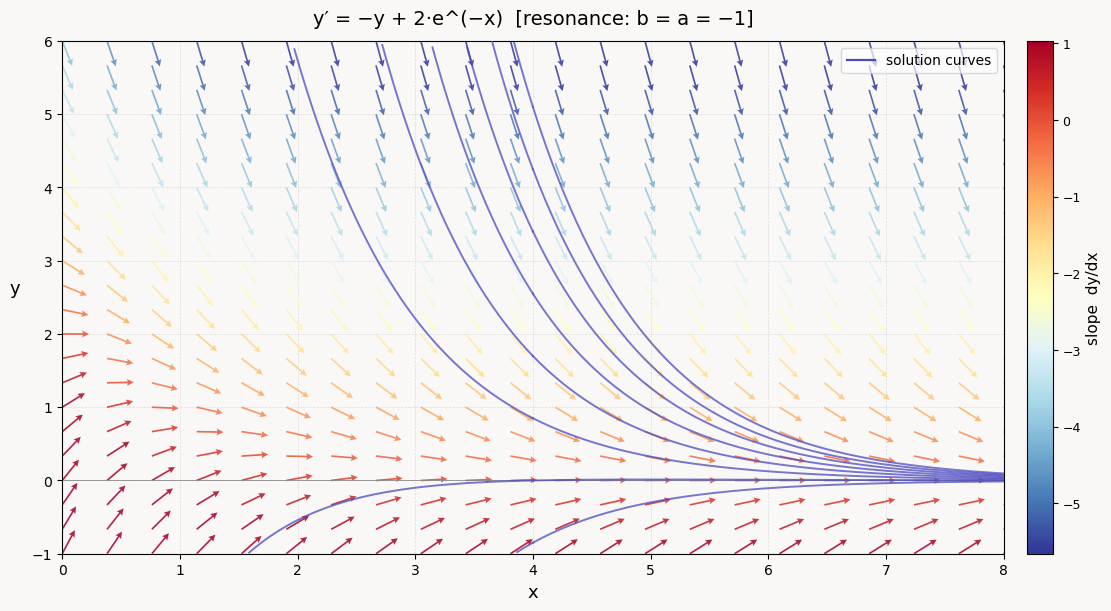

In [9]:

# ── resonance: b = a ──────────────────────────────────────────────────────────
# b = a = −1, so q(x) = 2·e^(−x) matches the homogeneous decay rate.
# Solution grows as x·e^(−x) — observe arrows steepening near x=0.
plot_vector_field(
    F       = lambda x, y: -y + 2.0 * np.exp(-np.asarray(x, float)),
    x_range = (0, 8),
    y_range = (-1, 6),
    density = 22,
    title   = "y′ = −y + 2·e^(−x)  [resonance: b = a = −1]",
    save_path='generated_plot_images/resonance_field.png',
)

---

# Worked examples — custom source functions

Beyond the four canonical sources covered by `linear_ode.py`, anything expressible as $F(x, y)$ in NumPy works as the right-hand side — including periodic, piecewise, unstable, and pulse-shaped systems.

## Sinusoidal forcing

$$y' = -y + \sin(x)$$

Steady periodic forcing produces a steady periodic response. The particular solution is

$$y_p(x) = \tfrac{1}{2}\!\left(\sin x - \cos x\right) = \tfrac{1}{\sqrt{2}}\sin\!\left(x - \tfrac{\pi}{4}\right)$$

— same frequency as the input, but phase-shifted and scaled by the system's transfer function.

Saved to generated_plot_images/sin_field.png


(<Figure size 1100x600 with 2 Axes>,
 <Axes: title={'center': 'y′ = −y + sin(x)'}, xlabel='x', ylabel='y'>)

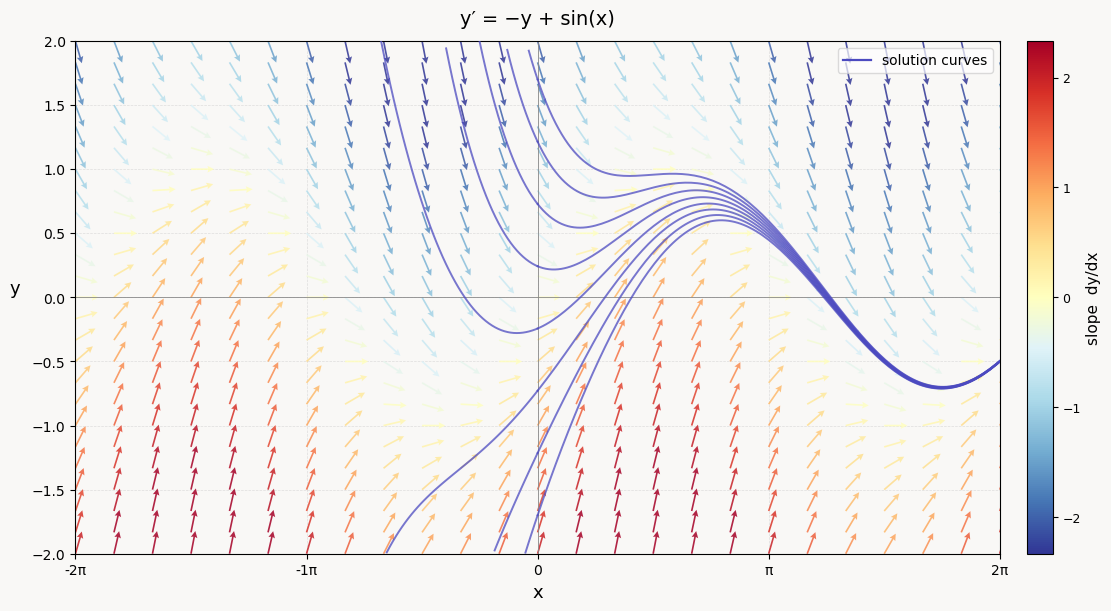

In [10]:
# y′ = −y + sin(x)
plot_vector_field(
    F       = lambda x, y: -y + np.sin(x),
    x_range = (-2 * np.pi, 2 * np.pi),
    y_range = (-2, 2),
    title   = "y′ = −y + sin(x)",
    save_path='generated_plot_images/sin_field.png',
)

## Piecewise source

A source that switches between multiple levels:

$$q(x) = \begin{cases} 0 & x < 2 \\ 1 & 2 \leq x < 5 \\ 2 & 5 \leq x < 8 \\ 0 & x \geq 8 \end{cases}$$

With $a = -0.5$, the system attempts to converge to each level's instantaneous steady state $y^{*} = -q / a = 2\,q$ before the next switch interrupts it — visible as a staircase of partial relaxations in the slope field.

$$y' = -0.5\,y + q(x)$$

Saved to generated_plot_images/piecewise_q_field.png


(<Figure size 1100x600 with 2 Axes>,
 <Axes: title={'center': 'y′ = −0.5y + piecewise q(x)'}, xlabel='x', ylabel='y'>)

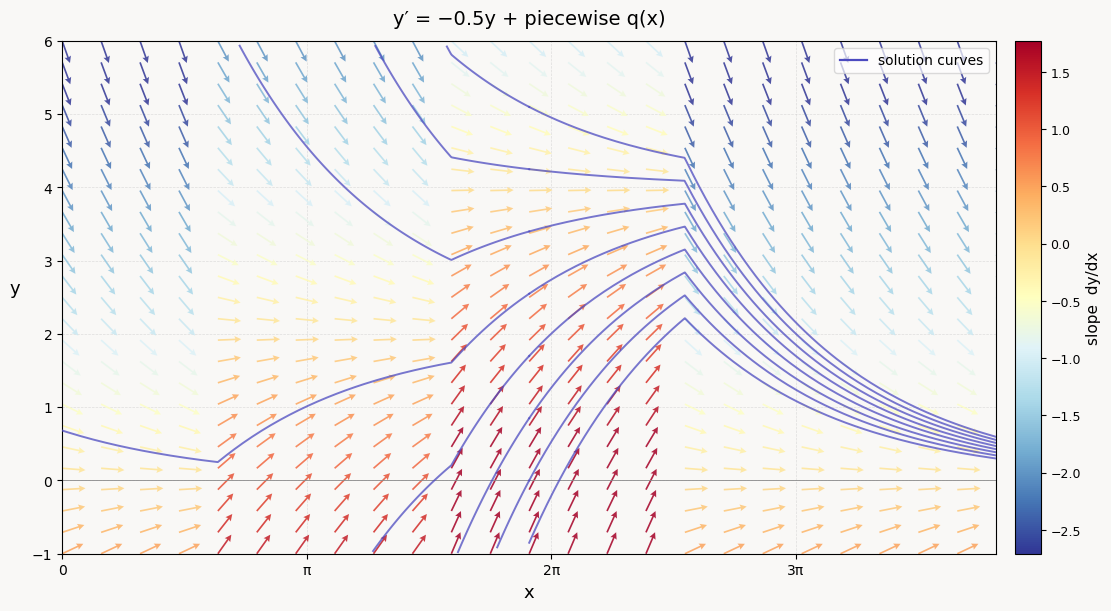

In [11]:
# Source switches on at x=2, doubles at x=5, off at x=8
def piecewise_q(x):
    x = np.asarray(x)
    return np.where(x < 2, 0, np.where(x < 5, 1.0, np.where(x < 8, 2.0, 0.0)))

plot_vector_field(
    F       = lambda x, y: -0.5 * y + piecewise_q(x),
    x_range = (0, 12),
    y_range = (-1, 6),
    title   = "y′ = −0.5y + piecewise q(x)",
    save_path='generated_plot_images/piecewise_q_field.png',
)

## Unstable system — $a > 0$

When $a > 0$ the homogeneous part $y_0\, e^{a x}$ **grows**, and any equilibrium becomes **unstable** — trajectories diverge away from it rather than toward it.

$$\frac{dy}{dx} = 0.5\,y - 3, \qquad y^{*} = \frac{3}{0.5} = 6 \text{ (unstable)}$$

Solutions starting above $y^{*} = 6$ blow up; solutions below it run off to $-\infty$. The equilibrium line acts as a **repeller** rather than an attractor.

Saved to generated_plot_images/unstable_field.png


(<Figure size 1100x600 with 2 Axes>,
 <Axes: title={'center': 'y′ = 0.5y − 3  [unstable, a > 0]'}, xlabel='x', ylabel='y'>)

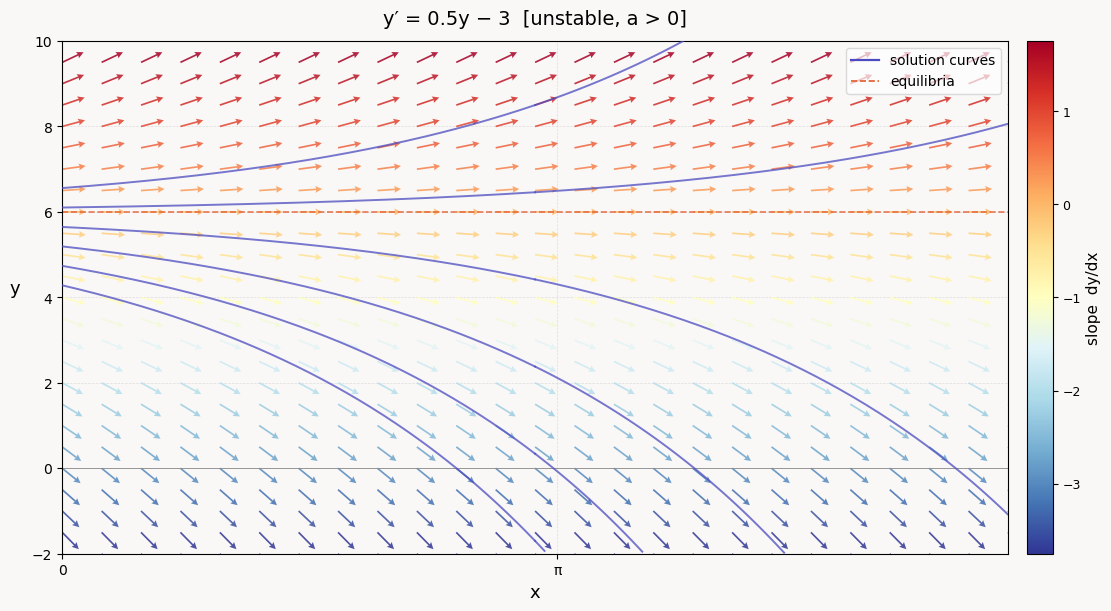

In [12]:
# a = +0.5: homogeneous part grows; source competes against it
plot_vector_field(
    F       = lambda x, y: 0.5 * y - 3.0,
    x_range = (0, 6),
    y_range = (-2, 10),
    n_curves= 6,
    title   = "y′ = 0.5y − 3  [unstable, a > 0]",
    save_path='generated_plot_images/unstable_field.png',
)

## Gaussian pulse source

A localised burst of forcing centred at $x = \mu$:

$$q(x) = A\, \exp\!\left(-\left(\frac{x - \mu}{\sigma}\right)^{\!2}\right), \qquad A = 4,\ \mu = 3,\ \sigma = 0.5$$

Far from $\mu$ the source is effectively zero and the system relaxes toward the homogeneous equilibrium $y = 0$. Near $\mu$ the system gets pushed sharply, producing a transient bump in the solution curve that subsequently decays back to zero.

$$y' = -y + q(x)$$

This is a smooth, finite-width approximation to a delta kick — and unlike the delta, the pulse is a proper function, so it shows up directly in the slope field.

Saved to generated_plot_images/gaussian_pulse.png


(<Figure size 1100x600 with 2 Axes>,
 <Axes: title={'center': 'y′ = −y + 4·exp(−((x−3)/0.5)²)  [Gaussian pulse]'}, xlabel='x', ylabel='y'>)

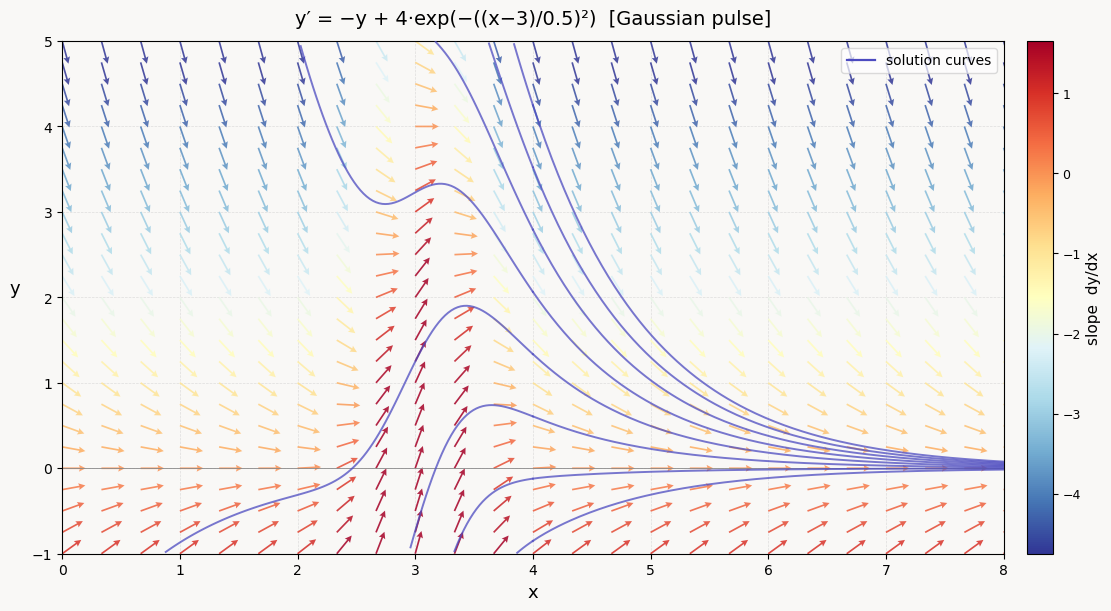

In [13]:
# Localised burst of forcing near x = 3
def gaussian_q(x, centre=3.0, width=0.5, amplitude=4.0):
    return amplitude * np.exp(-((np.asarray(x) - centre) / width) ** 2)

plot_vector_field(
    F       = lambda x, y: -y + gaussian_q(x),
    x_range = (0, 8),
    y_range = (-1, 5),
    title   = "y′ = −y + 4·exp(−((x−3)/0.5)²)  [Gaussian pulse]",
    save_path='generated_plot_images/gaussian_pulse.png',
)